In [1]:
import numpy as np
import torch
import random

def set_seed(seed=42):
    '''固定所有随机数'''
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

In [2]:
import h5py

file_path = "N-CMAPSS_DS02-006.h5"

with h5py.File(file_path, 'r') as f:
    #训练集
    W_dev = f['W_dev'][:]
    Xs_dev = f['X_s_dev'][:]
    A_dev = f['A_dev'][:]
    Y_dev = f['Y_dev'][:]
    X_s_var=f['X_s_var'][:]
    W_var=f['W_var'][:]
    #测试集 
    W_test = f['W_test'][:]
    Xs_test = f['X_s_test'][:]
    A_test = f['A_test'][:]
    Y_test = f['Y_test'][:]
#合并
X_dev = np.concatenate([W_dev, Xs_dev], axis=1)
X_test = np.concatenate([W_test, Xs_test], axis=1)
print(X_s_var,W_var)
#由于数据集是按照不同发动机单元构成的，所以必须按照这个区分开来，先记录每条记录的发动机序号
unit_dev = A_dev[:, 0].astype(int)
unit_test = A_test[:, 0].astype(int)
#min-max归一化，只用训练集防止数据泄露
X_min = X_dev.min(axis=0)
X_max = X_dev.max(axis=0)
denom = X_max - X_min + 1e-8#防止0

X_dev = 2 * (X_dev - X_min) / denom - 1
X_test = 2 * (X_test - X_min) / denom - 1

[b'T24' b'T30' b'T48' b'T50' b'P15' b'P2' b'P21' b'P24' b'Ps30' b'P40'
 b'P50' b'Nf' b'Nc' b'Wf'] [b'alt' b'Mach' b'TRA' b'T2']


In [3]:
from torch.utils.data import Dataset
#使用
class NCMAPSSDataset(Dataset):
    def __init__(self, X, Y, unit_array, window_size=50):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.float32).view(-1,1)#转torch
        self.unit = unit_array
        self.window_size = window_size

        self.valid_indices = []

        unique_units = np.unique(self.unit)

        for u in unique_units:
            indices = np.where(self.unit == u)[0]

            for i in range(len(indices) - window_size + 1):#实现根据不同的unit来创建滑动窗口
                self.valid_indices.append(indices[i])

        self.valid_indices = np.array(self.valid_indices)

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        start = self.valid_indices[idx]

        X_window = self.X[start:start+self.window_size]
        Y_target = self.Y[start+self.window_size-1]

        return X_window, Y_target
    
window_size = 50

full_dataset = NCMAPSSDataset(
    X_dev,
    Y_dev,
    unit_dev,
    window_size
)

In [4]:
unique_dev_units = np.unique(unit_dev)

# 最后一台开发集发动机作为验证集
val_unit = unique_dev_units[-1]
train_units = unique_dev_units[:-1]

train_mask = np.isin(unit_dev, train_units)
val_mask = unit_dev == val_unit

train_dataset = NCMAPSSDataset(
    X_dev[train_mask],
    Y_dev[train_mask],
    unit_dev[train_mask],
    window_size=50
)

val_dataset = NCMAPSSDataset(
    X_dev[val_mask],
    Y_dev[val_mask],
    unit_dev[val_mask],
    window_size=50
)

print("训练发动机：", train_units)
print("验证发动机：", val_unit)
print("训练窗口数：", len(train_dataset))
print("验证窗口数：", len(val_dataset))

训练发动机： [ 2  5 10 16 18]
验证发动机： 20
训练窗口数： 4495042
验证窗口数： 768111


In [5]:
from torch.utils.data import DataLoader

batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [6]:
import torch
import torch.nn as nn

class LSTMModel(nn.Module):
    def __init__(self, input_size=18):
        super(LSTMModel, self).__init__()

        # ===== 3 LSTM Layers =====
        self.lstm1 = nn.LSTM(
            input_size=input_size,
            hidden_size=20,
            batch_first=True
        )

        self.lstm2 = nn.LSTM(
            input_size=20,
            hidden_size=20,
            batch_first=True
        )

        self.lstm3 = nn.LSTM(
            input_size=20,
            hidden_size=20,
            batch_first=True
        )

        # ===== Fully Connected 50 =====
        self.fc1 = nn.Linear(20, 50)

        # ReLU Activation
        self.relu = nn.ReLU()

        # ===== Linear Output =====
        self.fc2 = nn.Linear(50, 1)

        # 初始化
        self._initialize_weights()
    def _initialize_weights(self):

        for name, param in self.named_parameters():

            if 'weight' in name:
                nn.init.xavier_uniform_(param)

            elif 'bias' in name:
                nn.init.zeros_(param)
    def forward(self, x):

        out, _ = self.lstm1(x)
        out, _ = self.lstm2(out)
        out, _ = self.lstm3(out)

        # 取最后时间步
        out = out[:, -1, :]

        out = self.fc1(out)
        out = self.relu(out)
        out = self.fc2(out)

        return out

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = LSTMModel().to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    amsgrad=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=1024,
    shuffle=True,
    drop_last=True
)
best_val_loss = float('inf')
patience = 5
counter = 0

max_epochs = 30

for epoch in range(max_epochs):

    model.train()
    train_loss = 0

    for X_batch, Y_batch in train_loader:

        X_batch = X_batch.to(device)
        Y_batch = Y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = criterion(outputs, Y_batch)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # ===== Validation =====
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for X_batch, Y_batch in val_loader:

            X_batch = X_batch.to(device)
            Y_batch = Y_batch.to(device)

            outputs = model(X_batch)

            loss = criterion(outputs, Y_batch)

            val_loss += loss.item()

    val_loss /= len(val_loader)

    print(f"Epoch {epoch+1}, Train: {train_loss:.4f}, Val: {val_loss:.4f}")

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), "best_model.pth")
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered.")
            break
torch.save(model.state_dict(), f"lstm_model_epoch_{epoch+1}_val{val_loss:.4f}.pth")

Epoch 1, Train: 460.3260, Val: 85.5455
Epoch 2, Train: 39.8156, Val: 87.3303
Epoch 3, Train: 35.7002, Val: 68.0689
Epoch 4, Train: 34.1909, Val: 103.3422
Epoch 5, Train: 33.3333, Val: 116.0669
Epoch 6, Train: 32.7660, Val: 108.9444
Epoch 7, Train: 32.1739, Val: 89.3855
Epoch 8, Train: 31.7950, Val: 109.4654
Early stopping triggered.


In [22]:
from tqdm import tqdm
import numpy as np
import torch

# ===== 构造 test loader =====
test_dataset = NCMAPSSDataset(
    X_test,
    Y_test,
    unit_test,
    window_size=50
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1024,
    shuffle=False
)

# ===== 加载模型 =====
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = LSTMModel().to(device)
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

# ===== 测试 =====
all_preds = []
all_targets = []

with torch.no_grad():
    for X_batch, Y_batch in tqdm(
        test_loader,
        desc="Testing",
        ncols=100
    ):

        X_batch = X_batch.to(device)
        Y_batch = Y_batch.to(device)

        outputs = model(X_batch)

        all_preds.append(outputs.cpu().numpy())
        all_targets.append(Y_batch.cpu().numpy())

# ===== 计算 RMSE =====
all_preds = np.vstack(all_preds)
all_targets = np.vstack(all_targets)

rmse = np.sqrt(np.mean((all_preds - all_targets) ** 2))

print(f"\nTest RMSE: {rmse:.4f}")

Testing: 100%|██████████████████████████████████████████████████| 1225/1225 [00:19<00:00, 62.37it/s]


Test RMSE: 6.0283


In [29]:
# 保存刚才Baseline的测试结果，防止后面rmse变量被覆盖
baseline_rmse = float(rmse)

print(f"Baseline Test RMSE: {baseline_rmse:.4f}")

# 将bytes变量名转换为字符串
sensor_names = [
    name.decode() if isinstance(name, bytes) else str(name)
    for name in X_s_var
]

condition_names = [
    name.decode() if isinstance(name, bytes) else str(name)
    for name in W_var
]

print("工况变量：", condition_names)
print("传感器变量：", sensor_names)

# 五个部件对应的传感器
component_sensor_names = {
    "Fan": ["P2", "P15", "P21", "Nf"],
    "LPC": ["T24", "P24", "Nf"],
    "HPC": ["T30", "Ps30", "Nc"],
    "HPT": ["T48", "P40", "Nc", "Wf"],
    "LPT": ["T50", "P50", "Nf"]
}

# X_dev前4列是工况，后14列是传感器
sensor_name_to_x_index = {
    name: 4 + sensor_names.index(name)
    for name in sensor_names
}

component_indices = {
    component: [
        sensor_name_to_x_index[name]
        for name in names
    ]
    for component, names in component_sensor_names.items()
}

for component in component_indices:
    print(
        component,
        component_sensor_names[component],
        component_indices[component]
    )

Baseline Test RMSE: 6.0283
工况变量： ['alt', 'Mach', 'TRA', 'T2']
传感器变量： ['T24', 'T30', 'T48', 'T50', 'P15', 'P2', 'P21', 'P24', 'Ps30', 'P40', 'P50', 'Nf', 'Nc', 'Wf']
Fan ['P2', 'P15', 'P21', 'Nf'] [9, 8, 10, 15]
LPC ['T24', 'P24', 'Nf'] [4, 11, 15]
HPC ['T30', 'Ps30', 'Nc'] [5, 12, 16]
HPT ['T48', 'P40', 'Nc', 'Wf'] [6, 13, 16, 17]
LPT ['T50', 'P50', 'Nf'] [7, 14, 15]


In [30]:
healthy_ratio = 0.20

healthy_mask = np.zeros(len(X_dev), dtype=bool)

# 使用你已经划分好的训练unit
for unit in train_units:
    unit_indices = np.where(unit_dev == unit)[0]

    healthy_count = max(
        1,
        int(len(unit_indices) * healthy_ratio)
    )

    healthy_indices_unit = unit_indices[:healthy_count]
    healthy_mask[healthy_indices_unit] = True

healthy_indices = np.where(healthy_mask)[0]

print("健康样本数量：", len(healthy_indices))
print("占开发集比例：", len(healthy_indices) / len(X_dev))
max_healthy_samples = 200_000

if len(healthy_indices) > max_healthy_samples:
    rng = np.random.default_rng(42)

    ae_train_indices = rng.choice(
        healthy_indices,
        size=max_healthy_samples,
        replace=False
    )
else:
    ae_train_indices = healthy_indices

print("实际用于AE训练的样本数量：", len(ae_train_indices))

健康样本数量： 899056
占开发集比例： 0.17081125733763444
实际用于AE训练的样本数量： 200000


In [31]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

class ConditionalComponentAE(nn.Module):
    def __init__(self, sensor_dim, latent_dim=2):
        super().__init__()

        self.condition_dim = 4

        # 编码器输入：4维工况 + 部件传感器
        self.encoder = nn.Sequential(
            nn.Linear(self.condition_dim + sensor_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, latent_dim)
        )

        # 解码器输入：2维latent + 4维工况
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim + self.condition_dim, 8),
            nn.ReLU(),
            nn.Linear(8, 16),
            nn.ReLU(),
            nn.Linear(16, sensor_dim)
        )

    def forward(self, model_input):
        # model_input前4列必须是工况
        conditions = model_input[:, :4]

        latent = self.encoder(model_input)

        # 关键：latent和工况拼接后再输入decoder
        decoder_input = torch.cat(
            [latent, conditions],
            dim=1
        )

        reconstructed = self.decoder(decoder_input)

        return reconstructed, latent

In [32]:
def train_component_ae(
    component_name,
    sensor_indices,
    epochs=15,
    batch_size=4096,
    learning_rate=1e-3
):
    # 前4列工况
    condition_indices = [0, 1, 2, 3]

    # AE输入：工况 + 部件传感器
    input_indices = condition_indices + sensor_indices

    X_ae_input = X_dev[
        ae_train_indices
    ][:, input_indices]

    # AE只重构部件传感器
    X_ae_target = X_dev[
        ae_train_indices
    ][:, sensor_indices]

    input_tensor = torch.tensor(
        X_ae_input,
        dtype=torch.float32
    )

    target_tensor = torch.tensor(
        X_ae_target,
        dtype=torch.float32
    )

    dataset = TensorDataset(
        input_tensor,
        target_tensor
    )

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True
    )

    model = ConditionalComponentAE(
            sensor_dim=len(sensor_indices),
            latent_dim=2
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    criterion_ae = nn.MSELoss()

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0

        for inputs, targets in loader:
            inputs = inputs.to(device)
            targets = targets.to(device)

            optimizer.zero_grad()

            reconstructed, latent = model(inputs)

            loss = criterion_ae(
                reconstructed,
                targets
            )

            loss.backward()
            optimizer.step()

            total_loss += (
                loss.item() * len(inputs)
            )

        average_loss = total_loss / len(dataset)

        if epoch == 0 or (epoch + 1) % 5 == 0:
            print(
                f"{component_name} | "
                f"Epoch {epoch + 1:02d} | "
                f"Loss = {average_loss:.6f}"
            )

    return model

In [33]:
set_seed(42)

component_models = {}

for component, indices in component_indices.items():
    print(f"\n开始训练 {component}-AE")

    component_models[component] = train_component_ae(
        component_name=component,
        sensor_indices=indices,
        epochs=15
    )


开始训练 Fan-AE
Fan | Epoch 01 | Loss = 0.154436
Fan | Epoch 05 | Loss = 0.003015
Fan | Epoch 10 | Loss = 0.000480
Fan | Epoch 15 | Loss = 0.000199

开始训练 LPC-AE
LPC | Epoch 01 | Loss = 0.118505
LPC | Epoch 05 | Loss = 0.000888
LPC | Epoch 10 | Loss = 0.000151
LPC | Epoch 15 | Loss = 0.000080

开始训练 HPC-AE
HPC | Epoch 01 | Loss = 0.113175
HPC | Epoch 05 | Loss = 0.002182
HPC | Epoch 10 | Loss = 0.000148
HPC | Epoch 15 | Loss = 0.000065

开始训练 HPT-AE
HPT | Epoch 01 | Loss = 0.169691
HPT | Epoch 05 | Loss = 0.002887
HPT | Epoch 10 | Loss = 0.000139
HPT | Epoch 15 | Loss = 0.000082

开始训练 LPT-AE
LPT | Epoch 01 | Loss = 0.211037
LPT | Epoch 05 | Loss = 0.002237
LPT | Epoch 10 | Loss = 0.000173
LPT | Epoch 15 | Loss = 0.000104


In [37]:
@torch.no_grad()
def calculate_component_error(
    model,
    X,
    sensor_indices,
    batch_size=8192
):
    model.eval()

    condition_indices = [0, 1, 2, 3]
    input_indices = condition_indices + sensor_indices

    all_errors = []

    for start in range(0, len(X), batch_size):
        end = min(start + batch_size, len(X))

        batch_input = torch.tensor(
            X[start:end, input_indices],
            dtype=torch.float32,
            device=device
        )

        batch_target = torch.tensor(
            X[start:end, sensor_indices],
            dtype=torch.float32,
            device=device
        )

        reconstructed, latent = model(batch_input)

        # 每条记录得到一个重构误差
        batch_error = torch.mean(
            (reconstructed - batch_target) ** 2,
            dim=1
        )

        all_errors.append(
            batch_error.cpu().numpy()
        )

    return np.concatenate(all_errors)

In [38]:
def convert_error_to_hi(
    dev_errors,
    test_errors,
    healthy_mask,
    train_mask
):
    # 健康阶段重构误差基准
    healthy_errors = dev_errors[healthy_mask]

    healthy_baseline = np.median(
        healthy_errors
    )

    # 使用训练集较高误差作为HI=1附近的参考值
    upper_reference = np.quantile(
        dev_errors[train_mask],
        0.995
    )

    denominator = max(
        upper_reference - healthy_baseline,
        1e-8
    )

    hi_dev = (
        dev_errors - healthy_baseline
    ) / denominator

    hi_test = (
        test_errors - healthy_baseline
    ) / denominator

    hi_dev = np.clip(hi_dev, 0.0, 1.0)
    hi_test = np.clip(hi_test, 0.0, 1.0)

    return hi_dev, hi_test
component_order = [
    "Fan",
    "LPC",
    "HPC",
    "HPT",
    "LPT"
]

hi_dev_dict = {}
hi_test_dict = {}

for component in component_order:
    print(f"正在计算 {component}-HI")

    indices = component_indices[component]
    model_component = component_models[component]

    dev_errors = calculate_component_error(
        model_component,
        X_dev,
        indices
    )

    test_errors = calculate_component_error(
        model_component,
        X_test,
        indices
    )

    hi_dev, hi_test = convert_error_to_hi(
        dev_errors,
        test_errors,
        healthy_mask,
        train_mask
    )

    hi_dev_dict[component] = hi_dev
    hi_test_dict[component] = hi_test

HI_dev = np.column_stack([
    hi_dev_dict[name]
    for name in component_order
])

HI_test = np.column_stack([
    hi_test_dict[name]
    for name in component_order
])

print("HI_dev形状：", HI_dev.shape)
print("HI_test形状：", HI_test.shape)

正在计算 Fan-HI
正在计算 LPC-HI
正在计算 HPC-HI
正在计算 HPT-HI
正在计算 LPT-HI
HI_dev形状： (5263447, 5)
HI_test形状： (1253743, 5)


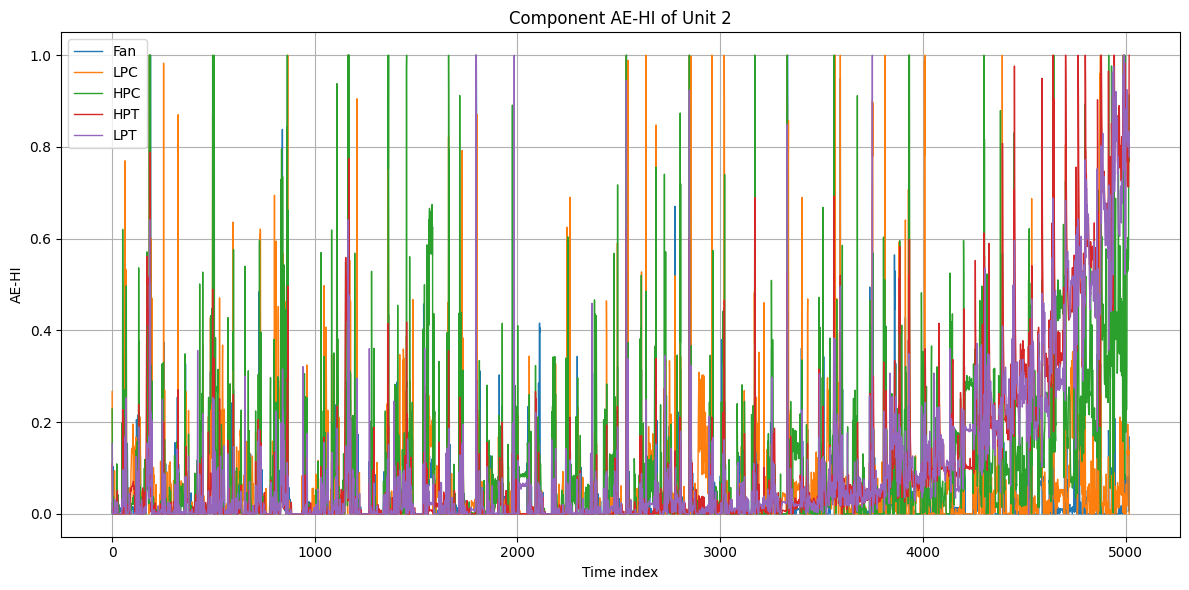


Unit 2
Fan: Spearman = 0.0677, p = 0.000e+00
LPC: Spearman = -0.0584, p = 0.000e+00
HPC: Spearman = -0.3566, p = 0.000e+00
HPT: Spearman = -0.6264, p = 0.000e+00
LPT: Spearman = -0.6680, p = 0.000e+00

Unit 5
Fan: Spearman = -0.0621, p = 0.000e+00
LPC: Spearman = -0.1555, p = 0.000e+00
HPC: Spearman = -0.4718, p = 0.000e+00
HPT: Spearman = -0.7373, p = 0.000e+00
LPT: Spearman = -0.7076, p = 0.000e+00

Unit 10
Fan: Spearman = -0.0499, p = 0.000e+00
LPC: Spearman = -0.0905, p = 0.000e+00
HPC: Spearman = -0.4457, p = 0.000e+00
HPT: Spearman = -0.6929, p = 0.000e+00
LPT: Spearman = -0.6761, p = 0.000e+00

Unit 16
Fan: Spearman = 0.0265, p = 1.467e-118
LPC: Spearman = -0.0639, p = 0.000e+00
HPC: Spearman = -0.4210, p = 0.000e+00
HPT: Spearman = -0.6836, p = 0.000e+00
LPT: Spearman = -0.7063, p = 0.000e+00

Unit 18
Fan: Spearman = 0.0075, p = 1.730e-12
LPC: Spearman = -0.0052, p = 8.725e-07
HPC: Spearman = -0.1963, p = 0.000e+00
HPT: Spearman = -0.7650, p = 0.000e+00
LPT: Spearman = -0.8117

In [39]:
import matplotlib.pyplot as plt

plot_unit = train_units[0]
plot_indices = np.where(unit_dev == plot_unit)[0]

# 如果点太多，降低绘图密度
plot_step = max(1, len(plot_indices) // 5000)
plot_indices_show = plot_indices[::plot_step]

plt.figure(figsize=(12, 6))

for i, component in enumerate(component_order):
    plt.plot(
        HI_dev[plot_indices_show, i],
        label=component,
        linewidth=1
    )

plt.xlabel("Time index")
plt.ylabel("AE-HI")
plt.title(f"Component AE-HI of Unit {plot_unit}")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
from scipy.stats import spearmanr
import numpy as np

# 确保RUL是一维
y_dev_flat = np.asarray(Y_dev).reshape(-1)

for unit in np.unique(unit_dev):
    mask = unit_dev == unit

    print(f"\nUnit {unit}")

    for i, component in enumerate(component_order):
        correlation, p_value = spearmanr(
            HI_dev[mask, i],
            y_dev_flat[mask]
        )

        print(
            f"{component}: "
            f"Spearman = {correlation:.4f}, "
            f"p = {p_value:.3e}"
        )

In [40]:
X_dev_aehi = np.concatenate(
    [X_dev, HI_dev],
    axis=1
)

X_test_aehi = np.concatenate(
    [X_test, HI_test],
    axis=1
)

print("Baseline输入维数：", X_dev.shape[1])
print("AE-HI增强输入维数：", X_dev_aehi.shape[1])

Baseline输入维数： 18
AE-HI增强输入维数： 23


In [41]:
train_dataset_aehi = NCMAPSSDataset(
    X_dev_aehi[train_mask],
    Y_dev[train_mask],
    unit_dev[train_mask],
    window_size=50
)

val_dataset_aehi = NCMAPSSDataset(
    X_dev_aehi[val_mask],
    Y_dev[val_mask],
    unit_dev[val_mask],
    window_size=50
)

test_dataset_aehi = NCMAPSSDataset(
    X_test_aehi,
    Y_test,
    unit_test,
    window_size=50
)

train_loader_aehi = DataLoader(
    train_dataset_aehi,
    batch_size=1024,
    shuffle=True,
    drop_last=True
)

val_loader_aehi = DataLoader(
    val_dataset_aehi,
    batch_size=1024,
    shuffle=False
)

test_loader_aehi = DataLoader(
    test_dataset_aehi,
    batch_size=1024,
    shuffle=False
)

print("训练窗口数：", len(train_dataset_aehi))
print("验证窗口数：", len(val_dataset_aehi))
print("测试窗口数：", len(test_dataset_aehi))

训练窗口数： 4495042
验证窗口数： 768111
测试窗口数： 1253596


In [42]:
set_seed(42)

model_aehi = LSTMModel(
    input_size=23
).to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model_aehi.parameters(),
    lr=0.001,
    amsgrad=True
)

best_val_loss = float("inf")
patience = 5
counter = 0
max_epochs = 30

for epoch in range(max_epochs):
    # ===== Training =====
    model_aehi.train()
    train_loss = 0.0

    for X_batch, Y_batch in train_loader_aehi:
        X_batch = X_batch.to(device)
        Y_batch = Y_batch.to(device)

        optimizer.zero_grad()

        outputs = model_aehi(X_batch)

        loss = criterion(outputs, Y_batch)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader_aehi)

    # ===== Validation =====
    model_aehi.eval()
    val_loss = 0.0

    with torch.no_grad():
        for X_batch, Y_batch in val_loader_aehi:
            X_batch = X_batch.to(device)
            Y_batch = Y_batch.to(device)

            outputs = model_aehi(X_batch)

            loss = criterion(outputs, Y_batch)
            val_loss += loss.item()

    val_loss /= len(val_loader_aehi)

    print(
        f"Epoch {epoch + 1}, "
        f"Train: {train_loss:.4f}, "
        f"Val: {val_loss:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0

        torch.save(
            model_aehi.state_dict(),
            "best_model_aehi.pth"
        )
    else:
        counter += 1

        if counter >= patience:
            print("Early stopping triggered.")
            break

Epoch 1, Train: 181.9150, Val: 66.7359
Epoch 2, Train: 38.9169, Val: 125.2935
Epoch 3, Train: 35.3564, Val: 106.3442
Epoch 4, Train: 33.8415, Val: 123.5957
Epoch 5, Train: 32.2740, Val: 110.3433
Epoch 6, Train: 31.5131, Val: 107.5884
Early stopping triggered.


In [43]:
from tqdm import tqdm

model_aehi = LSTMModel(
    input_size=23
).to(device)

model_aehi.load_state_dict(
    torch.load(
        "best_model_aehi.pth",
        map_location=device,
        weights_only=True
    )
)

model_aehi.eval()

aehi_preds = []
aehi_targets = []

with torch.no_grad():
    for X_batch, Y_batch in tqdm(
        test_loader_aehi,
        desc="Testing AE-HI model",
        ncols=100
    ):
        X_batch = X_batch.to(device)
        Y_batch = Y_batch.to(device)

        outputs = model_aehi(X_batch)

        aehi_preds.append(
            outputs.cpu().numpy()
        )

        aehi_targets.append(
            Y_batch.cpu().numpy()
        )

aehi_preds = np.vstack(aehi_preds)
aehi_targets = np.vstack(aehi_targets)

aehi_rmse = np.sqrt(
    np.mean(
        (aehi_preds - aehi_targets) ** 2
    )
)

print(f"\nBaseline RMSE: {baseline_rmse:.4f}")
print(f"AE-HI RMSE:    {aehi_rmse:.4f}")
print(
    f"RMSE变化:      "
    f"{aehi_rmse - baseline_rmse:+.4f}"
)

Testing AE-HI model:   0%|                                                 | 0/1225 [00:00<?, ?it/s]

Testing AE-HI model: 100%|██████████████████████████████████████| 1225/1225 [00:19<00:00, 61.90it/s]



Baseline RMSE: 6.0283
AE-HI RMSE:    6.7544
RMSE变化:      +0.7261
